# 2. How much did revenue fall from Q1 to Q2, and in which segment and which leaf?

**Week 2, Friday. Chapter 2 of 6.** Chapter 1 built the tree by segment for the half-year from the
customer table: Business carries 99.1 percent of the revenue, and Retail-Plus's basket, Rs 2,801 an
order against Retail-Core's Rs 1,886, separates the two consumer tiers. That table has no quarter, and
a split on each customer's last order date put Rs 17.88 crore in Q2, so this chapter opens the other
export the data team sent: the raw one, which carries each order's date.

> **The client asks.** "Monday's growth review deck needs three things I can open on my laptop
> without a login: the revenue tree by segment for both quarters, the top-fifty protect list with a
> lookup so I can find any member by id, and one number on the front page with its trend. Nothing
> that needs Python. If a director changes an assumption in the room, the sheet must recalculate in
> front of them."
>
> Meera's chief of staff, Kalpa Retail

**Who needs the answer.** The chief of staff needs the tree for both quarters on page two; Meera
decides from it which branch of the tree the growth plan funds. A pivot that counts some orders twice
puts nearly twice Finance's revenue in front of the directors and can call a falling segment healthy,
which sends the plan after the wrong segment.

**The questions on the way.**
1. Which way should the team split revenue by quarter, and what does each way cost?
2. What does the pivot say for Q1 and Q2?
3. Why does it read nearly double, and does Remove Duplicates fix it?
4. What does the tree say when each order counts once?
5. Which segment and which leaf fell?
6. Does the warehouse reach the same quarters by its own route?

**The metric at stake.** Revenue by quarter, booked order value in rupees: Q1 is April to June 2026 and
Q2 is July to September 2026, Kalpa's own quarters. Monday's warehouse queries put them at
Rs 10,00,00,000 and Rs 9,84,00,000, and every number on the deck has to tie to those.

**Who else faces it.** Every business that takes money through a payment gateway holds orders and
payments at different grains. Razorpay, the Indian payment gateway, says its orders feature
"Combines multiple payment attempts for a single order", and on part payments that "each partial
payment would have a unique payment_id, but will be tied to the same order_id" (Razorpay
documentation, Orders and Payment Links partial payments, checked 30 September 2026). An export of
payments therefore repeats its orders, and every merchant's finance team meets the question this
chapter answers.

**Setup.** The cell loads the raw export from `../data/` as text, adds Kalpa's quarter from each order
date (April to June is Q1), and defines `warehouse()`, which asks the Kalpa warehouse a question in
SQL and returns its rows. The warehouse is the Postgres database this Codespace loaded when it was
created; Monday and Tuesday queried it.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv
import pandas as pd

DATA = kit.data_dir()
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


def money(n):
    """Rupees the way Kalpa's finance team reads them: crore, lakh, or rupees in full."""
    sign, a = ("-" if n < 0 else ""), abs(n)
    return sign + (crore(a) if a >= 1e7 else lakh(a) if a >= 1e5 else kit.rupees(round(a)))


def change(before, after):
    """The change from before to after, measured on before, in percent."""
    return (after - before) / before * 100

raw = pd.read_csv(DATA / "C2_W02_D05_raw_export_STUDENT.csv", keep_default_na=False)
raw["quarter"] = raw["order_date"].str[5:7].astype(int).map(lambda m: "Q1" if m <= 6 else "Q2")


def warehouse(query):
    """Ask the Kalpa warehouse itself, the source of truth every sheet ties back to."""
    return [{k: (int(v) if hasattr(v, "as_integer_ratio") and not isinstance(v, float) else v)
             for k, v in row.items()} for row in kit.sql(query)]

print(f"{len(raw):,} rows and {len(raw.columns) - 1} columns:", ", ".join(c for c in raw.columns if c != "quarter"))

1,450 rows and 8 columns: order_id, customer_id, segment, channel, order_date, order_amount, paid_amount, paid_date


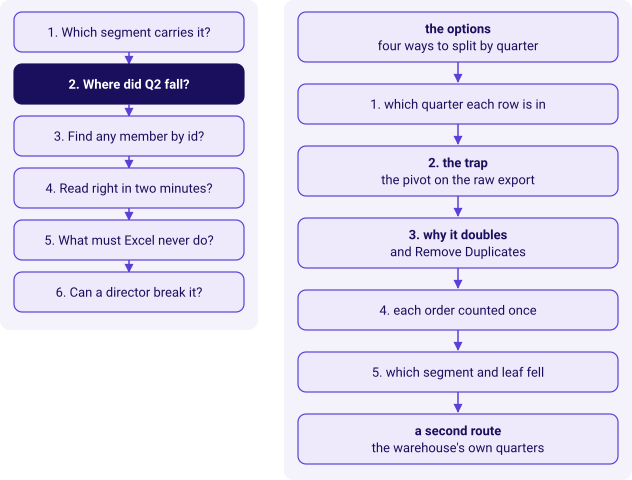

In [2]:
kit.side_by_side(
    kit.ladder(['Which segment carries it?', 'Where did Q2 fall?', 'Find any member by id?', 'Read right in two minutes?', 'What must Excel never do?', 'Can a director break it?'], lit=1, show=False),
    kit.vflow(['the options\nfour ways to split by quarter', '1. which quarter each row is in', '2. the trap\nthe pivot on the raw export', '3. why it doubles\nand Remove Duplicates', '4. each order counted once', '5. which segment and leaf fell', "a second route\nthe warehouse's own quarters"], show=False),
)

## Which way should the team split revenue by quarter, and what does each way cost?

| Option | How it splits | What it assumes |
|---|---|---|
| a) Split the customer table on the last order date | A customer's revenue goes to the quarter of their last order | Nobody bought in both quarters |
| b) A SUMIFS grid over the raw export, one formula per segment and quarter | Each formula adds the rows between a quarter's first and last date | The grid holds every slice anyone will ask for |
| c) Add Kalpa's quarter as a column, then pivot the raw export | April to June is Q1, July to September is Q2 | A director will want to re-slice it |
| d) Ask the data platform lead for the tree from the warehouse | The warehouse's own quarter column | The answer arrives before Monday, and again for every change a director asks for |

option,what it reads,what it risks on this data
a) last order date,300 customer rows,"170 customers bought in both quarters; their Q1 revenue, Rs 8.04 crore, lands in Q2"
b) SUMIFS grid,"8 formulas, each reading 1,450 rows on 3 conditions (34,800 tests)",recalculates at once; slices only the 8 cells built
c) quarter column and pivot,"1,450 formulas once, then 1 pivot",slices any column; recalculates on Refresh
d) ask the warehouse,the warehouse's orders,"exact, and a day's wait for every question a director asks"


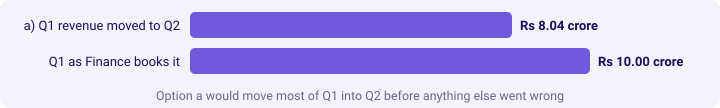

In [3]:
first_rows = raw.drop_duplicates("order_id")
bought = first_rows.groupby("customer_id")["quarter"].agg(set)
both = sum(1 for s in bought if s == {"Q1", "Q2"})
moved = int(first_rows[first_rows["customer_id"].isin(bought[bought.map(len) == 2].index)
                       & (first_rows["quarter"] == "Q1")]["order_amount"].sum())
sizing = [
    ("a) last order date", "300 customer rows", f"{both} customers bought in both quarters; their Q1 revenue, {money(moved)}, lands in Q2"),
    ("b) SUMIFS grid", f"8 formulas, each reading {len(raw):,} rows on 3 conditions ({8 * len(raw) * 3:,} tests)", "recalculates at once; slices only the 8 cells built"),
    ("c) quarter column and pivot", f"{len(raw):,} formulas once, then 1 pivot", "slices any column; recalculates on Refresh"),
    ("d) ask the warehouse", "the warehouse's orders", "exact, and a day's wait for every question a director asks"),
]
kit.table(["option", "what it reads", "what it risks on this data"], sizing, caption="The four options sized on this export")
kit.bars([("a) Q1 revenue moved to Q2", moved), ("Q1 as Finance books it", 100_000_000)], fmt=money,
         title="Option a would move most of Q1 into Q2 before anything else went wrong")

**The best-fit call: c, a column with Kalpa's own quarter, then the pivot.** It reads the order dates
the export carries, labels the quarters the way Finance does, and lets a director re-slice by
channel or city in the room, which b's eight fixed cells cannot. Option a moves Rs 8.04 crore of Q1
into Q2 before anything else goes wrong, and d is exact and too slow for a meeting. **The fact that
would change it:** a deadline far enough away for the warehouse team to answer, which makes d exact
and repeatable. Chapter 5 comes back to who owns which number.

## 1. Which quarter does each row of the export belong to?

In Excel the column is one formula filled down: `=IF(MONTH(E2)<=6,"Q1","Q2")`, where column E holds
`order_date`. The setup cell already added it here.

**Predict before you run.** Of the 1,450 rows, how many fall in Q1? a) about half; b) about a
quarter; c) all of them; d) none, the dates are text.

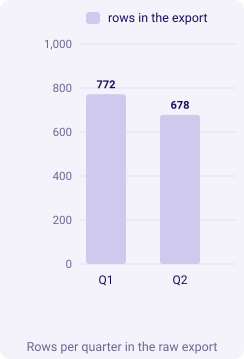

In [4]:
per_q = raw["quarter"].value_counts().reindex(["Q1", "Q2"])
kit.columns(["Q1", "Q2"], [("rows in the export", per_q.tolist())], title="Rows per quarter in the raw export")
kit.check("every row has a quarter", raw["quarter"].isin(["Q1", "Q2"]).all(), f"{per_q['Q1']} in Q1, {per_q['Q2']} in Q2")

**What happened.** The answer is a: 772 rows fall in Q1 and 678 in Q2. The dates read cleanly, and the
quarter column now matches Finance's labels, so the pivot is one drag away.

## 2. What does the pivot say for Q1 and Q2?

Build the chapter 1 pivot again on this export: `segment` in Rows, `quarter` in Columns, `order_amount`
in Values as Sum.

**Predict before you run.** The pivot's Q2 total reads about: a) Rs 9.84 crore, like the warehouse;
b) Rs 4.9 crore; c) Rs 19.5 crore; d) Rs 98 crore.

In [5]:
hurried = raw.pivot_table(index="segment", columns="quarter", values="order_amount", aggfunc="sum").reindex(SEGMENTS)
rows = [(s, kit.rupees(r.Q1), kit.rupees(r.Q2), f"{change(r.Q1, r.Q2):+.1f}%") for s, r in hurried.iterrows()]
rows.append(("All segments", kit.rupees(hurried.Q1.sum()), kit.rupees(hurried.Q2.sum()),
             f"{change(hurried.Q1.sum(), hurried.Q2.sum()):+.1f}%"))
kit.table(["Segment", "Q1", "Q2", "Change"], rows, caption="The pivot on the raw export: Sum of order_amount")
kit.stats([(crore(hurried.Q1.sum()), "Q1, as the pivot shows it", "the warehouse: Rs 10.00 crore"),
           (crore(hurried.Q2.sum()), "Q2, as the pivot shows it", "the warehouse: Rs 9.84 crore"),
           (f"{change(hurried.loc['Retail-Core', 'Q1'], hurried.loc['Retail-Core', 'Q2']):+.1f}%",
            "Retail-Core, Q1 to Q2", "the pivot calls it growing")])

Segment,Q1,Q2,Change
Business,"Rs 19,80,28,880","Rs 19,34,72,200",-2.3%
Retail-Core,"Rs 4,33,760","Rs 4,38,160",+1.0%
Retail-Plus,"Rs 9,38,160","Rs 7,00,910",-25.3%
Student,"Rs 35,350","Rs 48,070",+36.0%
All segments,"Rs 19,94,36,150","Rs 19,46,59,340",-2.4%


**What happened: the plausible wrong answer.** The answer is c. The pivot reads Rs 19,94,36,150 for
Q1 and Rs 19,46,59,340 for Q2, Rs 39,40,95,490 in all, and says Retail-Core grew 1.0 percent. Nothing
is red and every row is a real row of the export. The deck would carry Rs 19.47 crore for Q2, nearly
twice Finance's Rs 9.84 crore, and call Retail-Core the healthy segment the growth plan can leave
alone.

## 3. Why does it read nearly double, and does Remove Duplicates fix it?

**Why it is wrong.** A Sum adds one value per row, and the question is what one row of this export
stands for. **The check that catches it** takes a minute: count the rows against the distinct order
ids, then tie the grand total to the warehouse.

**Predict before you run.** After Excel's **Data, Remove Duplicates** with every column ticked, the
grand total reads: a) Rs 19.84 crore, the warehouse; b) still about Rs 39.4 crore; c) about half the
warehouse; d) nothing, because the tool refuses repeated ids.

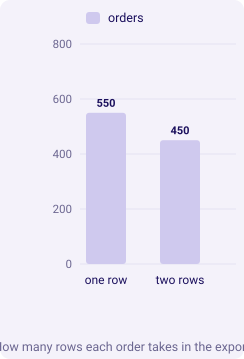

Version of the export,Rows,Grand total
As exported,"1,450","Rs 39,40,95,490"
"After Remove Duplicates, every column","1,400","Rs 39,40,57,740"
"The warehouse, Monday","1,000 orders","Rs 19,84,00,000"


In [6]:
rows_per_order = raw.groupby("order_id").size()
kit.stats([(f"{len(raw):,}", "rows", "in the export"),
           (f"{raw['order_id'].nunique():,}", "distinct order ids", "what the warehouse holds"),
           (f"{len(raw) / raw['order_id'].nunique():.2f}", "rows per order", "above 1.00 inflates a Sum")])
kit.columns(["one row", "two rows"], [("orders", [int((rows_per_order == 1).sum()), int((rows_per_order == 2).sum())])],
            title="How many rows each order takes in the export")
deduped = raw.drop(columns="quarter").drop_duplicates()
kit.table(["Version of the export", "Rows", "Grand total"],
          [("As exported", f"{len(raw):,}", kit.rupees(raw["order_amount"].sum())),
           ("After Remove Duplicates, every column", f"{len(deduped):,}", kit.rupees(deduped["order_amount"].sum())),
           ("The warehouse, Monday", "1,000 orders", kit.rupees(100_000_000 + 98_400_000))],
          caption="What Remove Duplicates changes")
kit.check("the export repeats orders: more rows than order ids", len(raw) > raw["order_id"].nunique(),
          f"{len(raw):,} rows, {raw['order_id'].nunique():,} ids")
kit.check("Remove Duplicates leaves the total nearly double the warehouse",
          deduped["order_amount"].sum() > 1.9 * 198_400_000, money(deduped["order_amount"].sum()))

**What happened.** The answer is b. The export has one row per **payment**, with the order's amount
repeated on each: 550 orders sit on one row and 450 on two. Remove Duplicates removes only rows that
are identical in every column, and 50 orders' two rows are identical, a payment the gateway posted
twice. The other 400 orders were paid in two instalments, so their two rows differ in `paid_amount`
and both stay. The total barely moves, from Rs 39,40,95,490 to Rs 39,40,57,740 on 1,400 rows, and the
analyst now believes the export is clean.

## 4. What does the tree say when each order counts once?

The fix names the grain: flag the first row of each order and add only flagged rows. In Excel the flag
is `=IF(COUNTIF($A$2:A2,A2)=1,1,0)` filled down column A's order ids, with the pivot or a SUMIFS reading
only rows where the flag is 1. The code below builds the same flag: a running count per order that
is 1 on the order's first row.

**Predict before you run.** Counted once per order, what is the Q2 total? a) Rs 9.84 crore; b) Rs 9.74
crore; c) Rs 19.47 crore; d) Rs 4.92 crore.

Segment,Q1,Q2,Change
Business,"Rs 9,90,14,440","Rs 9,75,84,600",-1.4%
Retail-Core,"Rs 3,73,070","Rs 3,66,250",-1.8%
Retail-Plus,"Rs 5,85,770","Rs 4,13,380",-29.4%
Student,"Rs 26,720","Rs 35,770",+33.9%
All segments,"Rs 10,00,00,000","Rs 9,84,00,000",-1.6%


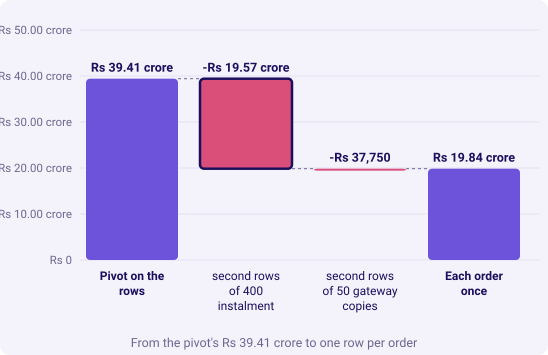

In [7]:
raw["first_row"] = (raw.groupby("order_id").cumcount() == 0).astype(int)   # =IF(COUNTIF($A$2:A2,A2)=1,1,0)
orders = raw[raw["first_row"] == 1]                                      # one row per order

once = orders.pivot_table(index="segment", columns="quarter", values="order_amount", aggfunc="sum").reindex(SEGMENTS)
rows = [(s, kit.rupees(r.Q1), kit.rupees(r.Q2), f"{change(r.Q1, r.Q2):+.1f}%") for s, r in once.iterrows()]
rows.append(("All segments", kit.rupees(once.Q1.sum()), kit.rupees(once.Q2.sum()), f"{change(once.Q1.sum(), once.Q2.sum()):+.1f}%"))
kit.table(["Segment", "Q1", "Q2", "Change"], rows, caption="The same pivot, each order counted once")
kit.bridge(("Pivot on the rows", int(raw["order_amount"].sum())),
           [("second rows of 400 instalment orders", -int(raw[(raw["first_row"] == 0) & (raw["paid_amount"] != raw["order_amount"])]["order_amount"].sum())),
            ("second rows of 50 gateway copies", -int(raw[(raw["first_row"] == 0) & (raw["paid_amount"] == raw["order_amount"])]["order_amount"].sum()))],
           end_label="Each order once", fmt=money, lit=(0,),
           title="From the pivot's Rs 39.41 crore to one row per order")
kit.check("each order is flagged exactly once", int(raw["first_row"].sum()) == raw["order_id"].nunique(), f"{int(raw['first_row'].sum()):,} flags")
kit.check("Retail-Core falls once each order counts once", once.loc["Retail-Core", "Q2"] < once.loc["Retail-Core", "Q1"],
          f"{change(once.loc['Retail-Core', 'Q1'], once.loc['Retail-Core', 'Q2']):+.1f}%")

**What happened.** The answer is a. Counted once per order, Q1 is Rs 10,00,00,000 and Q2 is
Rs 9,84,00,000, down 1.6 percent. **What changed:** the grand total falls by Rs 19,56,95,490 to the
warehouse's figure, and Retail-Core turns from a 1.0 percent rise into a 1.8 percent fall, Rs 3,73,070
to Rs 3,66,250. Most of the excess was instalment orders, which are the largest invoices; the 50
gateway copies are small consumer orders worth Rs 37,750.

## 5. Which segment and which leaf fell?

The company fell Rs 16,00,000, 1.6 percent. Two readings answer "where": the rupees each segment lost,
and the share of its own revenue each segment lost. The bridge below takes the rupees; the tree per
segment and quarter takes the leaves, using chapter 1's: customers who ordered, orders per customer
and revenue per order.

**Predict before you run.** Which Retail-Plus leaf moved most from Q1 to Q2? a) customers; b) orders
per customer; c) revenue per order; d) all three by about the same amount.

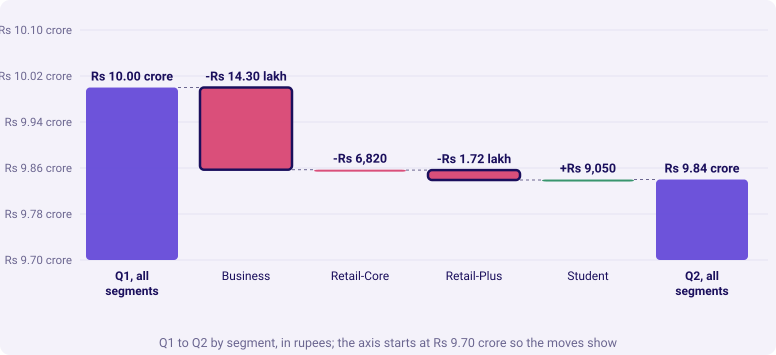

Retail-Plus,Q1,Q2,Change
Customers,91,76,-16.5%
Orders per customer,2.36,1.84,-22.0%
Revenue per order,"Rs 2,725","Rs 2,953",+8.4%
Revenue,"Rs 5,85,770","Rs 4,13,380",-29.4%


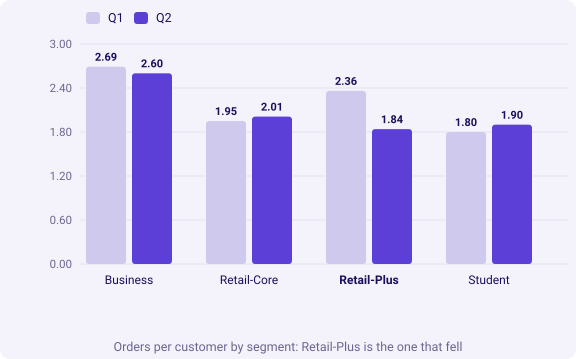

In [8]:
seg_q = orders.pivot_table(index="segment", columns="quarter", values="order_amount", aggfunc="sum").reindex(SEGMENTS)
kit.bridge(("Q1, all segments", int(seg_q["Q1"].sum())),
           [(s, int(seg_q.loc[s, "Q2"] - seg_q.loc[s, "Q1"])) for s in SEGMENTS],
           end_label="Q2, all segments", fmt=money, lit=(0, 2), lo=97_000_000,
           title="Q1 to Q2 by segment, in rupees; the axis starts at Rs 9.70 crore so the moves show")
leaves = (orders.groupby(["segment", "quarter"])
          .agg(customers=("customer_id", "nunique"), orders=("order_id", "count"), revenue=("order_amount", "sum")))
leaves["orders_per_customer"] = leaves["orders"] / leaves["customers"]
leaves["revenue_per_order"] = leaves["revenue"] / leaves["orders"]
p1, p2 = leaves.loc[("Retail-Plus", "Q1")], leaves.loc[("Retail-Plus", "Q2")]
kit.table(["Retail-Plus", "Q1", "Q2", "Change"],
          [("Customers", int(p1.customers), int(p2.customers), f"{change(p1.customers, p2.customers):+.1f}%"),
           ("Orders per customer", f"{p1.orders_per_customer:.2f}", f"{p2.orders_per_customer:.2f}", f"{change(p1.orders_per_customer, p2.orders_per_customer):+.1f}%"),
           ("Revenue per order", kit.rupees(round(p1.revenue_per_order)), kit.rupees(round(p2.revenue_per_order)), f"{change(p1.revenue_per_order, p2.revenue_per_order):+.1f}%"),
           ("Revenue", kit.rupees(p1.revenue), kit.rupees(p2.revenue), f"{change(p1.revenue, p2.revenue):+.1f}%")],
          caption="The Retail-Plus tree, each order counted once")
kit.columns(SEGMENTS, [("Q1", [round(leaves.loc[(s, "Q1"), "orders_per_customer"], 2) for s in SEGMENTS]),
                       ("Q2", [round(leaves.loc[(s, "Q2"), "orders_per_customer"], 2) for s in SEGMENTS])],
            fmt=lambda v: f"{v:.2f}", lit=(2,), title="Orders per customer by segment: Retail-Plus is the one that fell")
rebuilt = p2.customers * p2.orders_per_customer * p2.revenue_per_order
kit.check("the Retail-Plus Q2 tree multiplies back", abs(rebuilt - p2.revenue) < 1, kit.rupees(round(rebuilt)))

**What happened.** The answer is b. In rupees, Business carries most of the fall: Rs 14,29,840 of the
Rs 16,00,000, which is 1.4 percent of its own Q1, the size of a few corporate invoices landing in one
quarter or the next. The steepest fall is Retail-Plus, down 29.4 percent, from Rs 5,85,770 to
Rs 4,13,380. Its customers who ordered fell from 91 to 76 (16.5 percent), orders per customer fell from
2.36 to 1.84 (22.0 percent), and the basket grew from Rs 2,725 to Rs 2,953 (8.4 percent). Members kept
buying big baskets and bought less often, the frequency branch Week 1 found, now read from the export
the directors will see. Both readings are true, and chapter 4 decides how each goes on the front page.

## A second route: does the warehouse reach the same quarters by its own query?

The export was written from the warehouse, and a second route must be able to disagree with it, so it
asks the warehouse's own orders table, which holds one row per order and never saw the export. The
query is Monday's.

Quarter,Orders in the warehouse,Revenue in the warehouse,"The export, once per order"
Q1,538,"Rs 10,00,00,000","Rs 10,00,00,000"
Q2,462,"Rs 9,84,00,000","Rs 9,84,00,000"


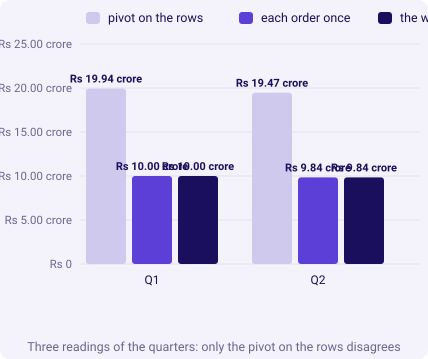

In [9]:
wq = warehouse("SELECT quarter, count(*) AS orders, sum(amount) AS revenue FROM orders GROUP BY quarter ORDER BY quarter")
kit.table(["Quarter", "Orders in the warehouse", "Revenue in the warehouse", "The export, once per order"],
          [(r["quarter"], r["orders"], kit.rupees(r["revenue"]), kit.rupees(int(once[r["quarter"]].sum()))) for r in wq])
kit.columns(["Q1", "Q2"], [("pivot on the rows", [int(hurried.Q1.sum()), int(hurried.Q2.sum())]),
                          ("each order once", [int(once.Q1.sum()), int(once.Q2.sum())]),
                          ("the warehouse", [r["revenue"] for r in wq])],
            fmt=money, title="Three readings of the quarters: only the pivot on the rows disagrees")
kit.check("the export counted once ties to the warehouse to the rupee, both quarters",
          all(int(once[r["quarter"]].sum()) == r["revenue"] for r in wq))
kit.check("the order counts tie too", all(int(orders[orders["quarter"] == r["quarter"]]["order_id"].nunique()) == r["orders"] for r in wq))

> **Kavya's review.** "The two exports came at two grains. Say the grain before you pivot, count rows
> against ids, and tie the grand total to the warehouse before the pivot goes anywhere. Remove
> Duplicates is a cleaning step with no record, and here it did not even clean."

### In the interview: where do you look first when a pivot disagrees with the warehouse?

**[F] Your pivot shows a different total from the warehouse. Where do you look first?** At the grain:
rows against distinct keys. A payment, item or event export repeats its parent's amount, and a Sum
adds every repeat. Here 1,450 rows held 1,000 orders and the pivot read Rs 39.41 crore against
Rs 19.84 crore. If the grain is right, I look at the period and the filters next, then at keys present
on one side and missing on the other.

**[S] Why does Remove Duplicates not fix an export at the payment grain?** It removes rows identical in
every column. Two instalments of one order differ in the amount paid, so both stay; only the 50 exact
gateway copies went, and the total moved from Rs 39,40,95,490 to Rs 39,40,57,740. The fix names the
grain: count each order once by its key.

**[D] The export grows a hundredfold. Which of today's formulas do you replace, and with what?** The
running COUNTIF flag. It compares each row with every row from the first down to its own, so 1,450 rows cost 1,051,975
comparisons and 145,000 rows cost about 10.5 billion, which freezes a laptop. I sort by order id and
flag a row whose id differs from the row above, one comparison a row, or I ask the warehouse for an
order-grain export and stop fixing the grain in a sheet at all.

### Depth: what does a payment gateway's own data say about orders and payments?

**What an order with two payments looks like.** Razorpay's Orders API returns an `attempts` field,
"The number of payment attempts, successful and failed, that have been made against this order",
and an `amount_paid` beside the order's `amount` (Razorpay API reference, Create an order, checked 30
September 2026). A merchant's analyst who exports payments and pivots on the order amount meets
this chapter's trap; one who sums `amount_paid` per order answers a collections question instead,
which is chapter 5's.

## How far did revenue fall, where, and does the warehouse agree, question by question?

1. A quarter column and the pivot, since a split on the last order date moves Rs 8.04 crore of Q1 into Q2; the column puts 772 rows in Q1 and 678 in Q2.
2. The pivot on the export's rows reads Rs 19,94,36,150 for Q1 and Rs 19,46,59,340 for Q2, and calls Retail-Core up 1.0 percent.
3. It doubles because one row is one payment: 1,450 rows for 1,000 orders; Remove Duplicates removes only the 50 identical gateway copies and leaves Rs 39,40,57,740.
4. Each order counted once: Q1 Rs 10,00,00,000, Q2 Rs 9,84,00,000, down 1.6 percent; Retail-Core is down 1.8 percent.
5. In rupees Business carries Rs 14.30 lakh of the Rs 16.00 lakh fall; the steepest fall is Retail-Plus, down 29.4 percent, because orders per customer fell from 2.36 to 1.84 while its basket grew 8.4 percent.
6. The warehouse's own query gives the same two quarters to the rupee.

The next question is chapter 3's: Retail-Plus members are ordering less often, so which of them does
the head of Retail-Plus protect first, and can the chief of staff look any of them up?

In [10]:
kit.check_summary()